# RiMEA 05: Premovement Time 

8 m x 5 m room, 1 m exit, 10 occupants. Impose pre-defined premovement distributions: uniformly distributed between 10 s and 100 s and verify each occupant starts moving within the specified range.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 19 June 2026, 16:58 CEST


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
import sys
from pathlib import Path

_PROJECT_ROOT = Path.cwd().parent  # standards/
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from utils.premovement_distributions import create_premovement_distribution

In [4]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and Run

In [5]:
%%capture
SCENARIO_ZIP = Path("scenario_files") / "Rimea-05-premovement.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
result = run_scenario(scenario, seed=42)

In [6]:
print(scenario.summary())
walkable = scenario.walkable_polygon
df = result.trajectory_dataframe()

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-05-premovement.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      2400s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~10
    jps-distributions_0: 10 agents


In [7]:
starts = []
for agent_id, sub in df.sort_values(['id', 'frame']).groupby('id'):
    x0, y0 = sub.iloc[0][['x', 'y']]
    moved = sub[(sub.x - x0).abs() + (sub.y - y0).abs() > 0.05]
    t = (moved.iloc[0]['frame'] / result.frame_rate) if len(moved) else float('nan')
    starts.append(t)
observed_starts = np.array(starts)
result.cleanup()

## Observed vs Analytic Premovement Times

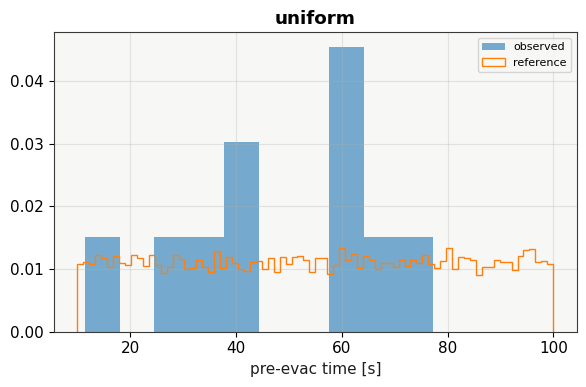

In [8]:
UNIFORM_PARAMS = {"a": 10.0, "b": 100.0}
fig, ax = plt.subplots(figsize=(6, 4))
obs = observed_starts[~np.isnan(observed_starts)]
if len(obs):
    ax.hist(obs, bins=10, density=True, alpha=0.6, label='observed')
ref = create_premovement_distribution("uniform", UNIFORM_PARAMS, seed=1).sample(10000)
ax.hist(ref, bins=80, density=True, histtype='step', label='reference')
ax.set_title('uniform'); ax.set_xlabel('pre-evac time [s]'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Acceptance

Each occupant must start within the distribution's support, and observed starts should be consistent with the assigned family (two-sample KS, alpha = 0.05).

In [9]:
from scipy import stats as _stats
ALPHA = 0.05
obs = observed_starts[~np.isnan(observed_starts)]
ref = create_premovement_distribution("uniform", UNIFORM_PARAMS, seed=2).sample(10000)
ks = _stats.ks_2samp(obs, ref) if len(obs) else None
fit = pd.DataFrame([{
    'case': 'uniform', 'n': int(len(obs)),
    'min_s': float(obs.min()) if len(obs) else float('nan'),
    'max_s': float(obs.max()) if len(obs) else float('nan'),
    'ks_p': ks.pvalue if ks else float('nan'),
}])
print(fit)
assert (fit['ks_p'] > ALPHA).all(), fit

      case   n  min_s  max_s      ks_p
0  uniform  10   11.4   77.3  0.273241
